- 머신러닝 / 딥러닝 쉬운 설명에 대한 오픈 커뮤니티 링크 : https://easy.prag-ai.com

# 머신러닝으로 할 수 있는 것
- 편지봉투에 손으로 쓴 우편번호 숫자 자동 판별
- 의료 영상 이미지에 기반한, 종양 판단
- 의심되는 신용카드 거래 감지
- 블로그 글의 주제 분류
- 고객들을 취향이 비슷한 그룹으로 묶기

# 문제와 데이터 이해하기

- 가지고 이는 데이터가 내가 원하는 문제의 답을 가지고 있는가?
- 내 문제를 가장 잘 해결할 수 있는 머신러닝 방법은 무엇인가
- 문제를 풀기에 충분한 데이터를 모았는가?
- 머신러닝의 성과를 어떻게 측정할 것인가

## 용어 및 설명

- 머신러닝 이해 : https://www.youtube.com/watch?v=KDrys0OnVho

# 머신러닝 : Supervised 

## Regression(회귀)과 Classification(분류)

### Regression 

- 예 ) 어떤 사람의 교육수준, 나이, 주거지를 바탕으로 연간 소득을 예측하는 것
- 예 ) 옥수수 농장에서 전년도 수확량과 날씨, 고용 인원수 등으로 올해 수확량을 예측하는 것

### Classifiation
- 예) 웹사이트가 어떤 언어로 되어있는가
- 예) 사진을 보고, 고양이 인지 강아지 인지, 소인지 분류

## Training 과 Test

훈련이란, 데이터를 입력하고, 그 결과인 레이블이 나오도록 만드는 과정.  
즉, 데이터와 레이블을 통해 학습을 시키는 과정  

테스트란, 학습이 완료된 분류기에 학습에 사용하지 않은 데이터를 넣어서 정답을 맞추는지 확인하는 작업

## Generalization (일반화)

모델이 처음 보는 데이터에 대해 정확하게 예측할 수 있으면 이를 훈련 세트에서 테스트 세트로 일반화되었다고 함.

## Overfiting (과대적합)  / Underfitting (과소적합)

오버핏팅이란 학습한 결과과, 학습에 사용된 데이터와 거의 일치하여, 새로운 데이터가 들어왔을 때, 예측이 틀려 버리는 상태

새로운 데이터에 일반화되기 어렵다.

언더핏팅은, 그 반대다.

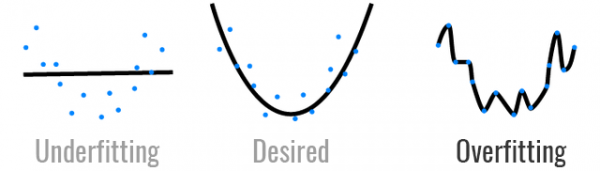

## 성능 측정

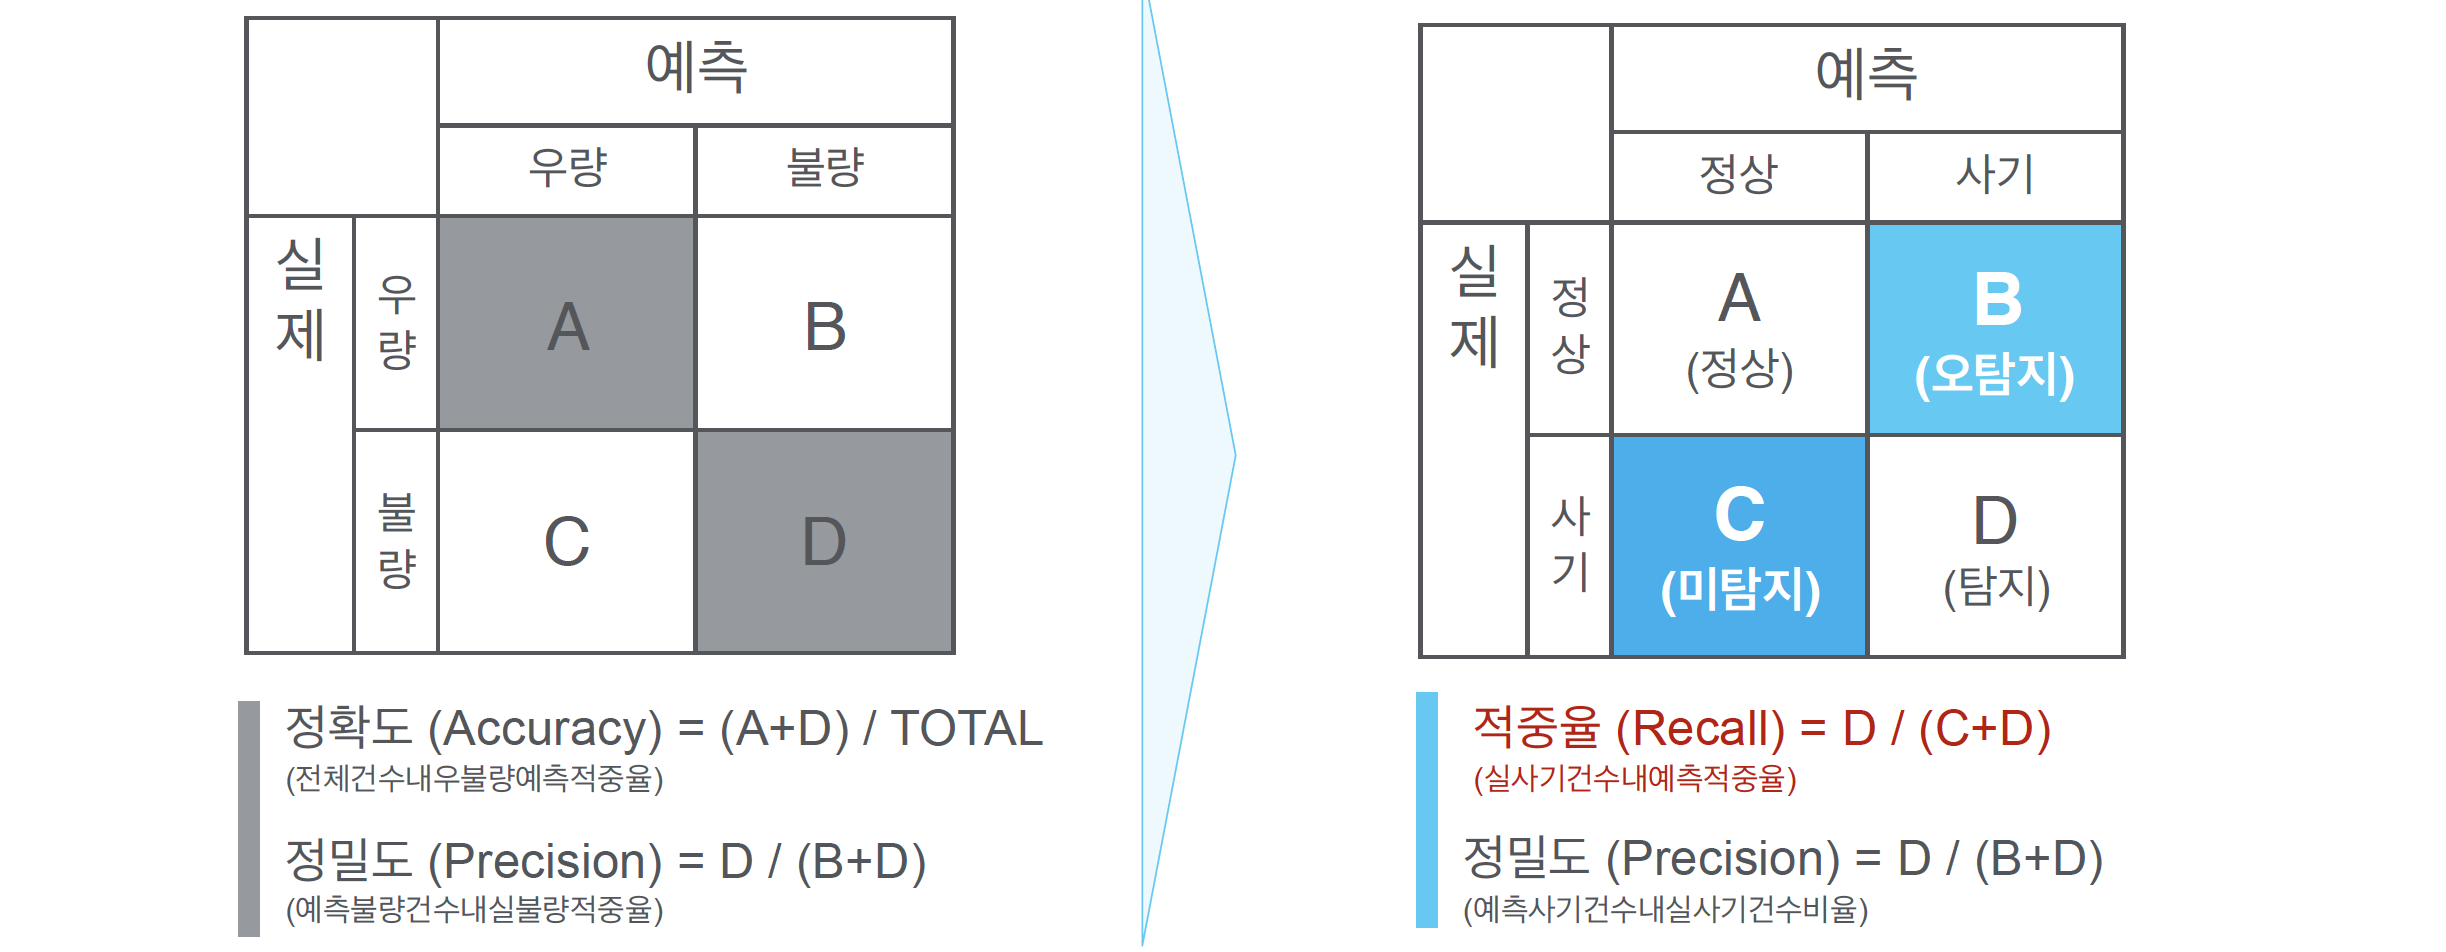

---

# sklearn 설치

만약 설치가 안되었으면 다음으로 설치함
- https://scikit-learn.org/stable/install.html

In [1]:
# pip install scikit-learn

## import library

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 데이터셋 로딩 및 df 만들기

In [3]:
df = pd.read_csv("./datas_ml/Data.csv")

In [4]:
# 온라인 소핑목 고객 데이터라고 가정, 이 소핑목에서 물건을 구매했으면, Purchased 가 yes
df.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [5]:
# 이 데이터를 가지고 인공지능 만들건데, 고객 데이터를 넣으면, 우리 쇼핑몰에서 물건을 구매할것 같은지 할거 같은지
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [6]:
sorted(df['Country'].unique())

['France', 'Germany', 'Spain']

In [7]:
# sorted(df['Purchased'].unique())
sorted(df['Purchased'].unique())

['No', 'Yes']

# 결측치(NaN) 처리 

In [8]:
# 결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    10 non-null     object 
 1   Age        9 non-null      float64
 2   Salary     9 non-null      float64
 3   Purchased  10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 448.0+ bytes


In [9]:
df.isna().sum()

Country      0
Age          1
Salary       1
Purchased    0
dtype: int64

### 1. nan을 삭제하는 전략

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
5,France,35.0,58000.0,Yes
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


### 2. 채우는 전략

In [11]:
# 0으로 채우기


,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,0.0,Yes
5,France,35.0,58000.0,Yes
6,Spain,0.0,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [12]:
# 평균으로 채우는 전략


Age          38.777778
Salary    63777.777778
dtype: float64

,Country,Age,Salary,Purchased
0,France,44.000000,72000.000000,No
1,Spain,27.000000,48000.000000,Yes
2,Germany,30.000000,54000.000000,No
3,Spain,38.000000,61000.000000,No
4,Germany,40.000000,63777.777778,Yes
5,France,35.000000,58000.000000,Yes
6,Spain,38.777778,52000.000000,No
7,France,48.000000,79000.000000,Yes
8,Germany,50.000000,83000.000000,No
9,France,37.000000,67000.000000,Yes


In [14]:
# 우리는 dropna() 선택


In [15]:
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
5,France,35.0,58000.0,Yes
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


# X, Y 데이터 분리
- 즉, 독립변수(X)와 종속변수(y)로 분리

In [16]:
df

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
5,France,35.0,58000.0,Yes
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


#### 구매를 할지 안할지를 예측하는 것을 해보자

In [18]:
X = 
X

,Country,Age,Salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
5,France,35.0,58000.0
7,France,48.0,79000.0
8,Germany,50.0,83000.0
9,France,37.0,67000.0


## 데이터를 확인했으면, 컴퓨터가 이해할 수 있도록 바꿔야 한다.

컴퓨터는 숫자로 처리한다.
숫자가 아닌 데이터 중에서, 카테고리로 판단되는 데이터는, 숫자로 바꿔줄 수 있다.

# 카테고리컬(Categorical) 문자 데이터 처리 방법

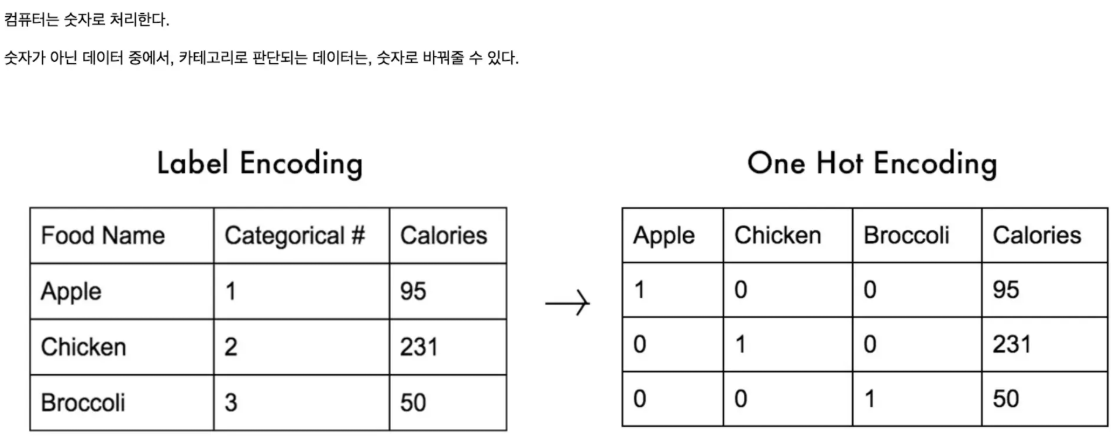
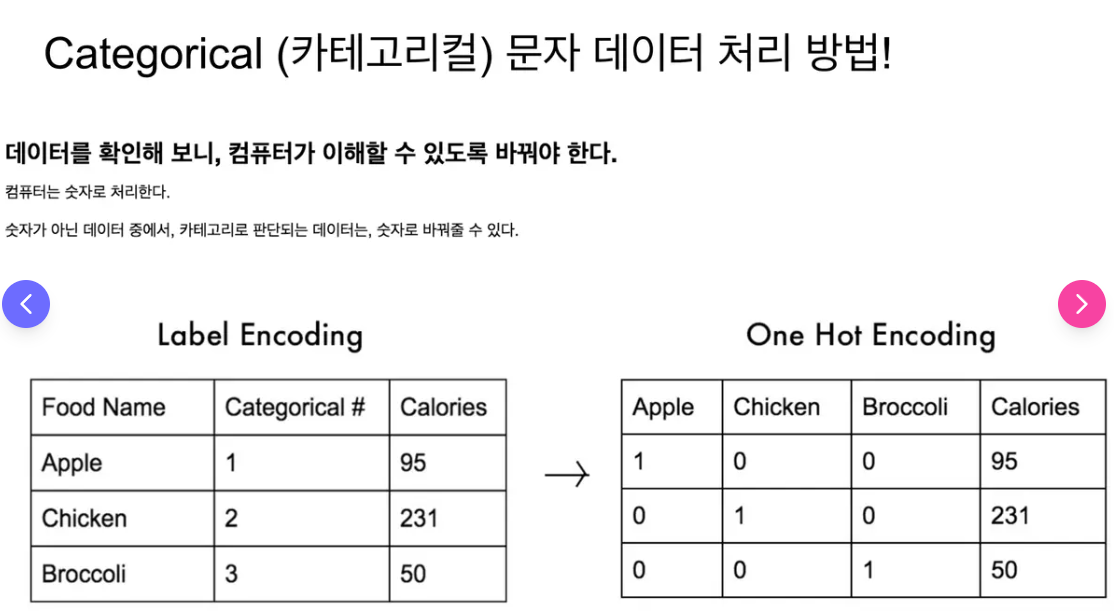

In [19]:
# 문자열 데이터를 확인한다 => 문자를 숫자로 바꿔줘야 함
# 1. 문자열 컬럼의 데이터가 몇개인지, 유니크한 갯수를 센다.
# 2. 갯수가 3개 이상이면 원핫인코딩을 해야학습이 잘 됨

In [20]:
X['Country'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [21]:
# 유니크 value의 갯수
X['Country'].nunique()

3

In [22]:
# 숫자로 변환
# 'France'  => 0
# 'Germany' => 1
# 'Spain'   => 2

In [23]:
X

,Country,Age,Salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
5,France,35.0,58000.0
7,France,48.0,79000.0
8,Germany,50.0,83000.0
9,France,37.0,67000.0


In [24]:
# 숫자 변환을 위한 라이브러리 로딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

## 1. 레이블인코딩 하는 방법

In [25]:
encoder = 

array([0, 2, 1, 2, 0, 0, 1, 0])

In [27]:

X

,Country,Age,Salary
0,0,44.0,72000.0
1,2,27.0,48000.0
2,1,30.0,54000.0
3,2,38.0,61000.0
5,0,35.0,58000.0
7,0,48.0,79000.0
8,1,50.0,83000.0
9,0,37.0,67000.0


## 2. 원 핫 인코딩하는 방법
- ct = ColumnTransformer( [('encoder', OneHotEncoder(), [0])] )
- [0] : X에 들어있는 원핫인코딩 하고 싶은 컬럼의 인데스를 써준다.

In [28]:
# ct = ColumnTransformer( [('encoder', OneHotEncoder(), [컬럼인덱스1, 컬럼인덱스2])] )
ct = 

In [29]:
# sort 안해도 됨


array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [30]:
# France, Germany, Spain
# [1.,    0.,     0.]  
# [0.,    0.,     1.]
# [0.,    1.,     0.]
# [0.,    0.,     1.]
# [1.,    0.,     0.]
# [1.,    0.,     0.]
# [0.,    1.,     0.]
# [1.,    0.,     0.]

In [31]:
# ct = ColumnTransformer( [('encoder', OneHotEncoder(), [컬럼인덱스1, 컬럼인덱스2])], remainder='passthrough' )
ct = 

# 컬럼 : France, Germany, Spain, Age, Salary

array([[1.0e+00, 0.0e+00, 0.0e+00, 4.4e+01, 7.2e+04],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.7e+01, 4.8e+04],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.0e+01, 5.4e+04],
       [0.0e+00, 0.0e+00, 1.0e+00, 3.8e+01, 6.1e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.5e+01, 5.8e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 4.8e+01, 7.9e+04],
       [0.0e+00, 1.0e+00, 0.0e+00, 5.0e+01, 8.3e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.7e+01, 6.7e+04]])

In [32]:
X = 

In [33]:
y.unique()

array(['No', 'Yes'], dtype=object)

In [34]:
y = 
y

array([0, 1, 0, 0, 1, 1, 0, 1])

- X, y  데이터 확인

In [35]:
X

array([[1.0e+00, 0.0e+00, 0.0e+00, 4.4e+01, 7.2e+04],
       [0.0e+00, 0.0e+00, 1.0e+00, 2.7e+01, 4.8e+04],
       [0.0e+00, 1.0e+00, 0.0e+00, 3.0e+01, 5.4e+04],
       [0.0e+00, 0.0e+00, 1.0e+00, 3.8e+01, 6.1e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.5e+01, 5.8e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 4.8e+01, 7.9e+04],
       [0.0e+00, 1.0e+00, 0.0e+00, 5.0e+01, 8.3e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.7e+01, 6.7e+04]])

In [36]:
y

array([0, 1, 0, 0, 1, 1, 0, 1])

# Feature Scaling
- 서로 다른 단위를 '같은 기준'으로 맞춰주기 위해
- 유클리디언 디스턴스로 오차를 줄여 나가는데, 하나의 변수는 오차가 크고, 하나의 변수는 오차가 작으면, 나중에 오차를 수정할때 편중되게 된다. 
- 따라서 값의 레인지를 맞춰줘야 정확히 트레이닝 된다.

### Age 와 Salary 는 같은 스케일이 아니다. 

- Age 는 27 ~ 50
- Salary 는 40k ~ 90k

## Feature Scaling 중 가장 많이 쓰는 방법

- 표준화(Standardisation) : 평균을 기준으로 얼마나 떨어져 있느냐? 같은 기준으로 만드는 방법, 음수도 존재, 데이터의 최대최소값 모를때 사용.
- 정규화(Normalisation) : 0 ~ 1 사이로 맞추는 것. 데이터의 위치 비교가 가능, 데이터의 최대최소값 알떄 사용

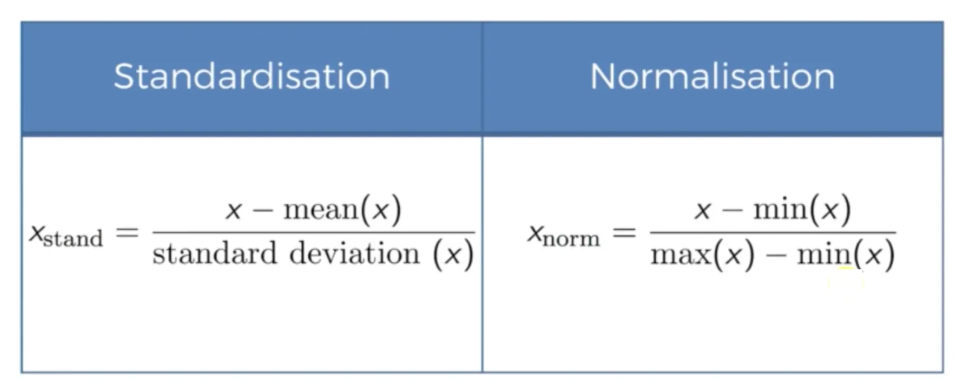
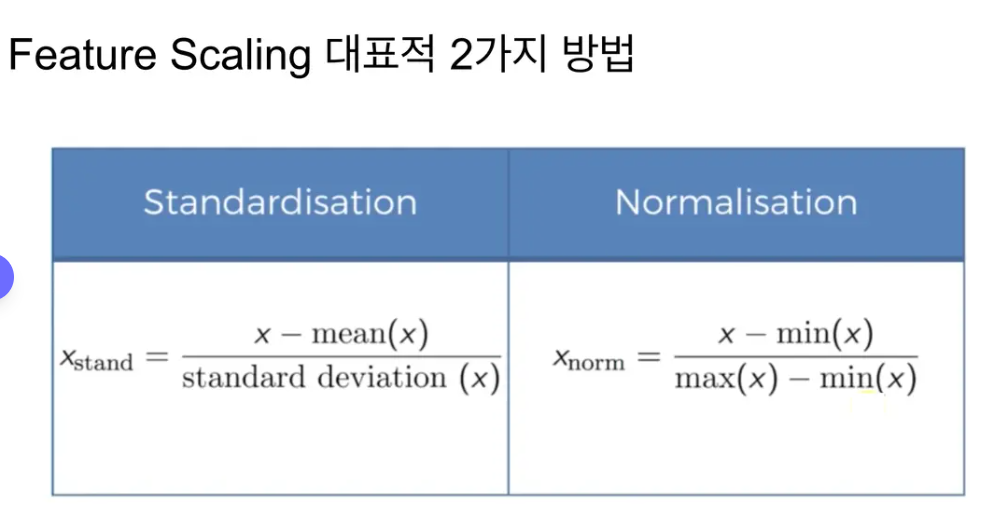

In [37]:
# 피처 스케일링 관련 클래스 로딩
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [38]:
# 1. 표준화(평균 0, 표준편차 1인 분포를 따르는 범위 데이터로 변환)


X_scaled

array([[ 1.        , -0.57735027, -0.57735027,  0.69985807,  0.58989097],
       [-1.        , -0.57735027,  1.73205081, -1.51364653, -1.50749915],
       [-1.        ,  1.73205081, -0.57735027, -1.12302807, -0.98315162],
       [-1.        , -0.57735027,  1.73205081, -0.08137885, -0.37141284],
       [ 1.        , -0.57735027, -0.57735027, -0.47199731, -0.6335866 ],
       [ 1.        , -0.57735027, -0.57735027,  1.22068269,  1.20162976],
       [-1.        ,  1.73205081, -0.57735027,  1.48109499,  1.55119478],
       [ 1.        , -0.57735027, -0.57735027, -0.211585  ,  0.1529347 ]])

In [39]:
# 2. 정규화(0~1 사이값으로 변환)

X_scaled

array([[1.        , 0.        , 0.        , 0.73913043, 0.68571429],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        , 0.13043478, 0.17142857],
       [0.        , 0.        , 1.        , 0.47826087, 0.37142857],
       [1.        , 0.        , 0.        , 0.34782609, 0.28571429],
       [1.        , 0.        , 0.        , 0.91304348, 0.88571429],
       [0.        , 1.        , 0.        , 1.        , 1.        ],
       [1.        , 0.        , 0.        , 0.43478261, 0.54285714]])

## Dataset을 Training 용과 Test용으로 나눈다.

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
# random_state=10 : 재현하기 위한 것


[array([[0.0e+00, 1.0e+00, 0.0e+00, 5.0e+01, 8.3e+04],
        [1.0e+00, 0.0e+00, 0.0e+00, 3.7e+01, 6.7e+04],
        [1.0e+00, 0.0e+00, 0.0e+00, 4.4e+01, 7.2e+04],
        [1.0e+00, 0.0e+00, 0.0e+00, 3.5e+01, 5.8e+04],
        [1.0e+00, 0.0e+00, 0.0e+00, 4.8e+01, 7.9e+04],
        [0.0e+00, 0.0e+00, 1.0e+00, 2.7e+01, 4.8e+04]]),
 array([[0.0e+00, 1.0e+00, 0.0e+00, 3.0e+01, 5.4e+04],
        [0.0e+00, 0.0e+00, 1.0e+00, 3.8e+01, 6.1e+04]]),
 array([0, 1, 0, 1, 1, 1]),
 array([0, 0])]

In [42]:
# 4개의 리턴값, 순서가 중요함


In [43]:
X_train

array([[1.        , 0.        , 0.        , 0.91304348, 0.88571429],
       [0.        , 0.        , 1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        , 0.34782609, 0.28571429],
       [1.        , 0.        , 0.        , 0.43478261, 0.54285714],
       [1.        , 0.        , 0.        , 0.73913043, 0.68571429],
       [0.        , 0.        , 1.        , 0.47826087, 0.37142857]])

- 이후, ML 학습하기

# 자동차 판매 예측

In [44]:
df = pd.read_csv('datas_ml/cars.csv')
df

,Brand,Model,Year,Mileage,EngineSize,FuelType,Color,Region,ConditionDesc,SellerType,Price
0,Ford,Escape,2001.0,287486.0,4.800248,Diesel,Black,Daejeon,like new,Dealer,580
1,Mercedes,E-Class,2014.0,168229.0,4.802429,Gasoline,White,Seoul,NaN,Dealer,1835
2,Mercedes,E-Class,2023.0,106081.0,3.293752,Gasoline,Red,Incheon,engine issue,Dealer,2226
3,Kia,Sorento,2009.0,89045.0,3.527349,Gasoline,NaN,Daegu,minor scratch on bumper,Dealer,1050
4,Ford,Escape,2005.0,34698.0,2.793782,Hybrid,Black,Seoul,NaN,Private,1290
...,...,...,...,...,...,...,...,...,...,...,...
295,Ford,Focus,2017.0,178352.0,2.289415,Diesel,Black,Daegu,slight dent,Private,1166
296,Kia,Sorento,2005.0,79459.0,4.239498,Hybrid,Black,Busan,needs painting,Dealer,1045
297,Hyundai,Tucson,2018.0,195004.0,2.018563,Gasoline,Gray,Seoul,no major problems,Dealer,1265
298,Mercedes,C-Class,2021.0,200968.0,3.726011,Gasoline,Black,Busan,no major problems,Dealer,1947


In [45]:
df.shape

(300, 11)

In [46]:
df.isna().sum()

Brand             0
Model             0
Year             15
Mileage          20
EngineSize        0
FuelType          0
Color            10
Region            8
ConditionDesc    25
SellerType        0
Price             0
dtype: int64

In [47]:
df_clean = df.dropna().copy()
df_clean

,Brand,Model,Year,Mileage,EngineSize,FuelType,Color,Region,ConditionDesc,SellerType,Price
0,Ford,Escape,2001.0,287486.0,4.800248,Diesel,Black,Daejeon,like new,Dealer,580
2,Mercedes,E-Class,2023.0,106081.0,3.293752,Gasoline,Red,Incheon,engine issue,Dealer,2226
6,Ford,Explorer,2023.0,22671.0,2.314658,EV,Black,Daegu,regular maintenance done,Private,2058
8,Mercedes,E-Class,2001.0,51663.0,4.009498,Diesel,Gray,Daejeon,dashboard damage,Private,1371
9,BMW,X5,2020.0,15708.0,4.166316,Hybrid,Black,Busan,noise in suspension,Private,2342
...,...,...,...,...,...,...,...,...,...,...,...
295,Ford,Focus,2017.0,178352.0,2.289415,Diesel,Black,Daegu,slight dent,Private,1166
296,Kia,Sorento,2005.0,79459.0,4.239498,Hybrid,Black,Busan,needs painting,Dealer,1045
297,Hyundai,Tucson,2018.0,195004.0,2.018563,Gasoline,Gray,Seoul,no major problems,Dealer,1265
298,Mercedes,C-Class,2021.0,200968.0,3.726011,Gasoline,Black,Busan,no major problems,Dealer,1947


In [48]:
df_clean.shape

(227, 11)

In [49]:
# y
y = df['Price']
y

0       580
1      1835
2      2226
3      1050
4      1290
       ... 
295    1166
296    1045
297    1265
298    1947
299    1489
Name: Price, Length: 300, dtype: int64

In [50]:
X = df_clean.drop('Price', axis=1)
X

,Brand,Model,Year,Mileage,EngineSize,FuelType,Color,Region,ConditionDesc,SellerType
0,Ford,Escape,2001.0,287486.0,4.800248,Diesel,Black,Daejeon,like new,Dealer
2,Mercedes,E-Class,2023.0,106081.0,3.293752,Gasoline,Red,Incheon,engine issue,Dealer
6,Ford,Explorer,2023.0,22671.0,2.314658,EV,Black,Daegu,regular maintenance done,Private
8,Mercedes,E-Class,2001.0,51663.0,4.009498,Diesel,Gray,Daejeon,dashboard damage,Private
9,BMW,X5,2020.0,15708.0,4.166316,Hybrid,Black,Busan,noise in suspension,Private
...,...,...,...,...,...,...,...,...,...,...
295,Ford,Focus,2017.0,178352.0,2.289415,Diesel,Black,Daegu,slight dent,Private
296,Kia,Sorento,2005.0,79459.0,4.239498,Hybrid,Black,Busan,needs painting,Dealer
297,Hyundai,Tucson,2018.0,195004.0,2.018563,Gasoline,Gray,Seoul,no major problems,Dealer
298,Mercedes,C-Class,2021.0,200968.0,3.726011,Gasoline,Black,Busan,no major problems,Dealer


# 문자열 데이터 처리

In [51]:
# 컬럼 삭제
X = X.drop('ConditionDesc', axis=1)

In [52]:
X

,Brand,Model,Year,Mileage,EngineSize,FuelType,Color,Region,SellerType
0,Ford,Escape,2001.0,287486.0,4.800248,Diesel,Black,Daejeon,Dealer
2,Mercedes,E-Class,2023.0,106081.0,3.293752,Gasoline,Red,Incheon,Dealer
6,Ford,Explorer,2023.0,22671.0,2.314658,EV,Black,Daegu,Private
8,Mercedes,E-Class,2001.0,51663.0,4.009498,Diesel,Gray,Daejeon,Private
9,BMW,X5,2020.0,15708.0,4.166316,Hybrid,Black,Busan,Private
...,...,...,...,...,...,...,...,...,...
295,Ford,Focus,2017.0,178352.0,2.289415,Diesel,Black,Daegu,Private
296,Kia,Sorento,2005.0,79459.0,4.239498,Hybrid,Black,Busan,Dealer
297,Hyundai,Tucson,2018.0,195004.0,2.018563,Gasoline,Gray,Seoul,Dealer
298,Mercedes,C-Class,2021.0,200968.0,3.726011,Gasoline,Black,Busan,Dealer


In [53]:
# X 문자열 컬럼 2개인지, 3개 이상인지 확인
X['Brand'].nunique()

5

In [54]:
X['Model'].nunique()

20

In [55]:
X['FuelType'].nunique()

4

In [56]:
X['Color'].nunique()

6

In [57]:
X['Region'].nunique()

5

In [58]:
X['SellerType'].nunique()

2

- 컬럼 범주 데이터에서 범주의 갯수가 많을 경우
- 컬럼 30개 있는데, 메모리 좀 더 큰것을 해야할 것 같다.

## 인코딩할 칼럼 구분
- 레이블 인코딩 할 칼럼
- 원한 인코딩할 칼럼
- 숫자 데이터 -> 피처스케일링 해야함

In [59]:
X.head()

,Brand,Model,Year,Mileage,EngineSize,FuelType,Color,Region,SellerType
0,Ford,Escape,2001.0,287486.0,4.800248,Diesel,Black,Daejeon,Dealer
2,Mercedes,E-Class,2023.0,106081.0,3.293752,Gasoline,Red,Incheon,Dealer
6,Ford,Explorer,2023.0,22671.0,2.314658,EV,Black,Daegu,Private
8,Mercedes,E-Class,2001.0,51663.0,4.009498,Diesel,Gray,Daejeon,Private
9,BMW,X5,2020.0,15708.0,4.166316,Hybrid,Black,Busan,Private


In [60]:
X.columns

Index(['Brand', 'Model', 'Year', 'Mileage', 'EngineSize', 'FuelType', 'Color',
       'Region', 'SellerType'],
      dtype='object')

## 현업방법 - 데이터 전처리

In [61]:
label_cols = ['SellerType']
onehot_cols = ['Brand', 'Model', 'FuelType', 'Color', 'Region']
numeric_cols = [ 'Year', 'Mileage', 'EngineSize']

In [62]:
from sklearn.preprocessing import OrdinalEncoder

In [63]:
ct = ColumnTransformer([ ('label', OrdinalEncoder(), label_cols),
                   ('onehot', OneHotEncoder(), onehot_cols),
                   ('scaler', StandardScaler(), numeric_cols) ] )

In [64]:
ct

,transformers,"[('label', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [65]:
# sparse matrix로 표현
print(ct.fit_transform(X))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1917 stored elements and shape (227, 44)>
  Coords	Values
  (0, 2)	1.0
  (0, 11)	1.0
  (0, 26)	1.0
  (0, 30)	1.0
  (0, 38)	1.0
  (0, 41)	-0.9249768106545554
  (0, 42)	1.7880660195193743
  (0, 43)	1.5429197838977786
  (1, 5)	1.0
  (1, 10)	1.0
  (1, 28)	1.0
  (1, 33)	1.0
  (1, 39)	1.0
  (1, 41)	1.4354392304332764
  (1, 42)	-0.3546402183717234
  (1, 43)	0.2937526938363846
  (2, 0)	1.0
  (2, 2)	1.0
  (2, 12)	1.0
  (2, 27)	1.0
  (2, 30)	1.0
  (2, 37)	1.0
  (2, 41)	1.4354392304332764
  (2, 42)	-1.3398563221312474
  (2, 43)	-0.5180987553925732
  :	:
  (224, 3)	1.0
  (224, 23)	1.0
  (224, 28)	1.0
  (224, 32)	1.0
  (224, 40)	1.0
  (224, 41)	0.8989810392769509
  (224, 42)	0.6956939333439961
  (224, 43)	-0.7636173326615148
  (225, 5)	1.0
  (225, 9)	1.0
  (225, 28)	1.0
  (225, 30)	1.0
  (225, 36)	1.0
  (225, 41)	1.2208559539707462
  (225, 42)	0.7661390699321965
  (225, 43)	0.6521764959891053
  (226, 0)	1.0
  (226, 2)	1.0
  (226, 11)	1.0

- 이후, ML 학습